### Nome: Arthur Felipe Reis Souza, Matrícula: 2021013884.

### O notebook está em ingles visto que estou fazendo a imersão no ingles (irei fazer a prova de Cambridge em 3 meses, então estou no processo de imersão.)

In [1]:
%pwd

'/home/arthur/Desktop/FINAL_PROJECT_ML'

In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip list

Package                 Version
----------------------- -----------
asttokens               3.0.0
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
fonttools               4.60.1
ipykernel               7.1.0
ipython                 9.7.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.2
jupyter_client          8.6.3
jupyter_core            5.9.1
kiwisolver              1.4.9
matplotlib              3.10.7
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.3.4
packaging               25.0
pandas                  2.3.3
parso                   0.8.5
pexpect                 4.9.0
pillow                  12.0.0
pip                     24.0
platformdirs            4.5.0
prompt_toolkit          3.0.52
psutil                  7.1.3
ptyprocess              0.7.0
pure_eval               0.2

In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


# 1- Analyzing and pre-processing the data:

### 1.1 - Opening the file an reading it, and making a general analysis.

In [5]:
# taking the path of the files and opening them
folder_data='/home/arthur/Desktop/FINAL_PROJECT_ML/FINAL_PROJECT_ML/data/'
files=os.listdir(folder_data)
print(f"The files inside the folder are: {files}")

The files inside the folder are: ['df_train.csv', 'df_test.csv', 'df_train_encoded.csv', 'df_test_encoded.csv']


In [6]:
df_train = pd.read_csv(os.path.join(folder_data, 'df_train.csv'))

In [7]:
df_train.head()

,id,garden_points_status,commitment_months,participation_history,project_focus_code,requested_resources_value,personal_reserve_status,volunteer_tenure_bracket,time_commitment_rate,household_profile,...,asset_contribution_type,member_age,other_support_plans,housing_situation,existing_commitments_count,role_skill_tier,dependents_supported,has_phone,newcomer_status,support_outcome
0,829,Points negative,36.0,Previous roles completed,Transport (used),8335.0,No reserve,>=7,3.0,Single adult,...,No tangible assets,47.0,NaN,Hosted / no rent,1.0,Skilled volunteer,1.0,No phone,Newcomer,bad
1,998,No points account,12.0,Previous roles completed,Communications equipment,804.0,Reserve: <100,>=7,4.0,Single adult,...,Shared tools,38.0,NaN,Own housing,1.0,Skilled volunteer,1.0,No phone,Newcomer,good
2,149,Points negative,36.0,Issues on prior roles,Workshop equipment,5371.0,Reserve: <100,1<=X<4,3.0,Single adult,...,Long-term fund,28.0,NaN,Own housing,2.0,Skilled volunteer,1.0,No phone,Newcomer,good
3,736,Points 0–199,36.0,All roles on time,Shared appliances,3990.0,No reserve,<1,3.0,Adult w/ dependents or shared household,...,No tangible assets,29.0,Partner bank,Own housing,1.0,Unemployed / non-resident unskilled,1.0,No phone,Newcomer,good
4,131,Points 0–199,48.0,Previous roles completed,Transport (new),8487.0,No reserve,4<=X<7,1.0,Adult w/ dependents or shared household,...,Shared tools,24.0,NaN,Own housing,1.0,Skilled volunteer,1.0,No phone,Newcomer,good


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             800 non-null    int64  
 1   garden_points_status           800 non-null    object 
 2   commitment_months              800 non-null    float64
 3   participation_history          800 non-null    object 
 4   project_focus_code             800 non-null    object 
 5   requested_resources_value      800 non-null    float64
 6   personal_reserve_status        800 non-null    object 
 7   volunteer_tenure_bracket       800 non-null    object 
 8   time_commitment_rate           800 non-null    float64
 9   household_profile              800 non-null    object 
 10  co_sponsor_presence            800 non-null    object 
 11  years_in_neighborhood_bracket  800 non-null    float64
 12  asset_contribution_type        800 non-null    obj

In [9]:
# Counting the number of NaN values in each column of the training dataset
for column in df_train.columns:
    num_missing = df_train[column].isna().sum()
    print(f"Column '{column}' has {num_missing} missing values.")

Column 'id' has 0 missing values.
Column 'garden_points_status' has 0 missing values.
Column 'commitment_months' has 0 missing values.
Column 'participation_history' has 0 missing values.
Column 'project_focus_code' has 0 missing values.
Column 'requested_resources_value' has 0 missing values.
Column 'personal_reserve_status' has 0 missing values.
Column 'volunteer_tenure_bracket' has 0 missing values.
Column 'time_commitment_rate' has 0 missing values.
Column 'household_profile' has 0 missing values.
Column 'co_sponsor_presence' has 0 missing values.
Column 'years_in_neighborhood_bracket' has 0 missing values.
Column 'asset_contribution_type' has 0 missing values.
Column 'member_age' has 0 missing values.
Column 'other_support_plans' has 649 missing values.
Column 'housing_situation' has 0 missing values.
Column 'existing_commitments_count' has 0 missing values.
Column 'role_skill_tier' has 0 missing values.
Column 'dependents_supported' has 0 missing values.
Column 'has_phone' has 0 

### 1.2 - In the analysis, I noted the high number of missing values in the column other_support_plans, then I investigated it more:

In [10]:
# Excluding the column other_support_plans due to high number of missing values (649/800)=~81%
df_train['other_support_plans'].value_counts()
print(f"The percentage of NaN values was: {df_train['other_support_plans'].isna().sum()/len(df_train)*100:.2f}%")
df_train = df_train.drop(columns=['other_support_plans'])

The percentage of NaN values was: 81.12%


In [11]:
x_train = df_train.drop(columns=['support_outcome'])
y_train = df_train['support_outcome']

### 1.3 - Splitting the dataset into value-labels:

In [12]:
# Splitting the data into features and target variable
x_train = df_train.drop(columns=['support_outcome'])
y_train = df_train['support_outcome']

### 1.4 - Verifying if this is a balanced dataset:

In [13]:
# Verifying if is a balanced dataset
y_train.value_counts(normalize=False)
print(f"The dataset is imbalanced since there are more 'good' outcomes than 'bad' ones.")
print(f"The proportion of 'good' outcomes is {y_train.value_counts(normalize=True)['good']:.1%} and 'bad' outcomes is {y_train.value_counts(normalize=True)['bad']:.1%}.")

The dataset is imbalanced since there are more 'good' outcomes than 'bad' ones.
The proportion of 'good' outcomes is 70.0% and 'bad' outcomes is 30.0%.


In [14]:
# Verifying if there are duplicate rows in the training dataset
num_duplicates = df_train.duplicated().sum()
print(f"The number of duplicate rows in the training dataset is: {num_duplicates}")

The number of duplicate rows in the training dataset is: 0


### 1.4 - Transforming the categories columns into useful information:

In [15]:
# Identifying categorical and numerical columns
categorical_cols = x_train.select_dtypes(include=['object']).columns
numerical_cols = x_train.select_dtypes(include=[np.number]).columns
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: Index(['garden_points_status', 'participation_history', 'project_focus_code',
       'personal_reserve_status', 'volunteer_tenure_bracket',
       'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
       'housing_situation', 'role_skill_tier', 'has_phone', 'newcomer_status'],
      dtype='object')
Numerical columns: Index(['id', 'commitment_months', 'requested_resources_value',
       'time_commitment_rate', 'years_in_neighborhood_bracket', 'member_age',
       'existing_commitments_count', 'dependents_supported'],
      dtype='object')


In [16]:
# counting the number of categories for each categorical column
for col in categorical_cols:
    num_categories = x_train[col].nunique()
    print(f"Column '{col}' has {num_categories} unique categories.")
    print(f"The categories are: {df_train[col].unique()}\n")

Column 'garden_points_status' has 4 unique categories.
The categories are: ['Points negative' 'No points account' 'Points 0–199' 'Points 200+']

Column 'participation_history' has 5 unique categories.
The categories are: ['Previous roles completed' 'Issues on prior roles' 'All roles on time'
 'No prior roles / all on time' 'Delayed in prior commitments']

Column 'project_focus_code' has 10 unique categories.
The categories are: ['Transport (used)' 'Communications equipment' 'Workshop equipment'
 'Shared appliances' 'Transport (new)' 'Training / education' 'Retraining'
 'Plot repairs' 'Other project' 'Microenterprise support']

Column 'personal_reserve_status' has 5 unique categories.
The categories are: ['No reserve' 'Reserve: <100' 'Reserve: 100–499' 'Reserve: ≥1000'
 'Reserve: 500–999']

Column 'volunteer_tenure_bracket' has 5 unique categories.
The categories are: ['>=7' '1<=X<4' '<1' '4<=X<7' 'unemployed']

Column 'household_profile' has 4 unique categories.
The categories are: ['S

In [ ]:
#Ordinal Encoding
ordinal_cols = [
    'garden_points_status', 
    'personal_reserve_status', 
    'role_skill_tier'
]

garden_points_categories = ['Points negative', 'No points account', 'Points 0–199', 'Points 200+']
personal_reserve_categories = ['No reserve', 'Reserve: <100', 'Reserve: 100–499', 'Reserve: 500–999', 'Reserve: ≥1000']
role_skill_categories = ['Unemployed / non-resident unskilled', 'Unskilled resident', 'Skilled volunteer', 'Highly skilled / lead']

# Nominal Encoding
nominal_cols = [
    'participation_history', 'project_focus_code', 'volunteer_tenure_bracket', 
    'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
    'housing_situation', 'has_phone', 'newcomer_status'
]

# Numerical columns
numerical_cols = [
    'commitment_months', 'requested_resources_value', 'time_commitment_rate', 
    'years_in_neighborhood_bracket', 'member_age', 'existing_commitments_count', 
    'dependents_supported'
]

In [ ]:
# 4. Create the ColumnTransformer
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[
            garden_points_categories, 
            personal_reserve_categories, 
            role_skill_categories
        ]), ordinal_cols),
        
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        
        ('numeric', 'passthrough', numerical_cols)
    ],
    remainder='drop'
)

In [19]:
# 5. Applying the new preprocessing OHE:
x_train_processed = preprocessor_tree.fit_transform(x_train)
x_train_processed

array([[ 0.,  0.,  2., ..., 47.,  1.,  1.],
       [ 1.,  1.,  2., ..., 38.,  1.,  1.],
       [ 0.,  1.,  2., ..., 28.,  2.,  1.],
       ...,
       [ 1.,  1.,  2., ..., 43.,  1.,  1.],
       [ 0.,  0.,  2., ..., 23.,  2.,  1.],
       [ 1.,  1.,  2., ..., 33.,  1.,  1.]], shape=(800, 48))

In [20]:
# Get the new feature names for the tree plot
ohe_feature_names = preprocessor_tree.named_transformers_['onehot'].get_feature_names_out(nominal_cols)
all_feature_names = ordinal_cols + list(ohe_feature_names) + numerical_cols

In [ ]:
# Create the processed DataFrame
df_train_encoded = pd.DataFrame(x_train_processed, columns=all_feature_names, index=x_train.index)

print("New processed training data shape:", df_train_encoded.shape)
df_train_encoded.head()

New processed training data shape: (800, 48)


,garden_points_status,personal_reserve_status,role_skill_tier,participation_history_All roles on time,participation_history_Delayed in prior commitments,participation_history_Issues on prior roles,participation_history_No prior roles / all on time,participation_history_Previous roles completed,project_focus_code_Communications equipment,project_focus_code_Microenterprise support,...,has_phone_No phone,newcomer_status_Local resident,newcomer_status_Newcomer,commitment_months,requested_resources_value,time_commitment_rate,years_in_neighborhood_bracket,member_age,existing_commitments_count,dependents_supported
0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,36.0,8335.0,3.0,4.0,47.0,1.0,1.0
1,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,12.0,804.0,4.0,4.0,38.0,1.0,1.0
2,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,5371.0,3.0,2.0,28.0,2.0,1.0
3,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,3990.0,3.0,2.0,29.0,1.0,1.0
4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,48.0,8487.0,1.0,2.0,24.0,1.0,1.0


In [22]:
df_train_encoded

,garden_points_status,personal_reserve_status,role_skill_tier,participation_history_All roles on time,participation_history_Delayed in prior commitments,participation_history_Issues on prior roles,participation_history_No prior roles / all on time,participation_history_Previous roles completed,project_focus_code_Communications equipment,project_focus_code_Microenterprise support,...,has_phone_No phone,newcomer_status_Local resident,newcomer_status_Newcomer,commitment_months,requested_resources_value,time_commitment_rate,years_in_neighborhood_bracket,member_age,existing_commitments_count,dependents_supported
0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,36.0,8335.0,3.0,4.0,47.0,1.0,1.0
1,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,12.0,804.0,4.0,4.0,38.0,1.0,1.0
2,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,5371.0,3.0,2.0,28.0,2.0,1.0
3,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,36.0,3990.0,3.0,2.0,29.0,1.0,1.0
4,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,48.0,8487.0,1.0,2.0,24.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,6.0,1237.0,1.0,1.0,27.0,2.0,1.0
796,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,24.0,1333.0,4.0,2.0,43.0,2.0,2.0
797,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,18.0,2515.0,3.0,4.0,43.0,1.0,1.0
798,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,18.0,8471.0,1.0,2.0,23.0,2.0,1.0


In [23]:
# verifying if there's a categorical
for col in df_train_encoded.columns:
    if df_train_encoded[col].dtype == 'object':
        print(f"Categorical column found: {col}")

In [24]:
# Encoding good to 1 and bad to 0
y_train = y_train.map({'good': 1, 'bad': 0})

### 1.5 - Analysing the correlation between the columns

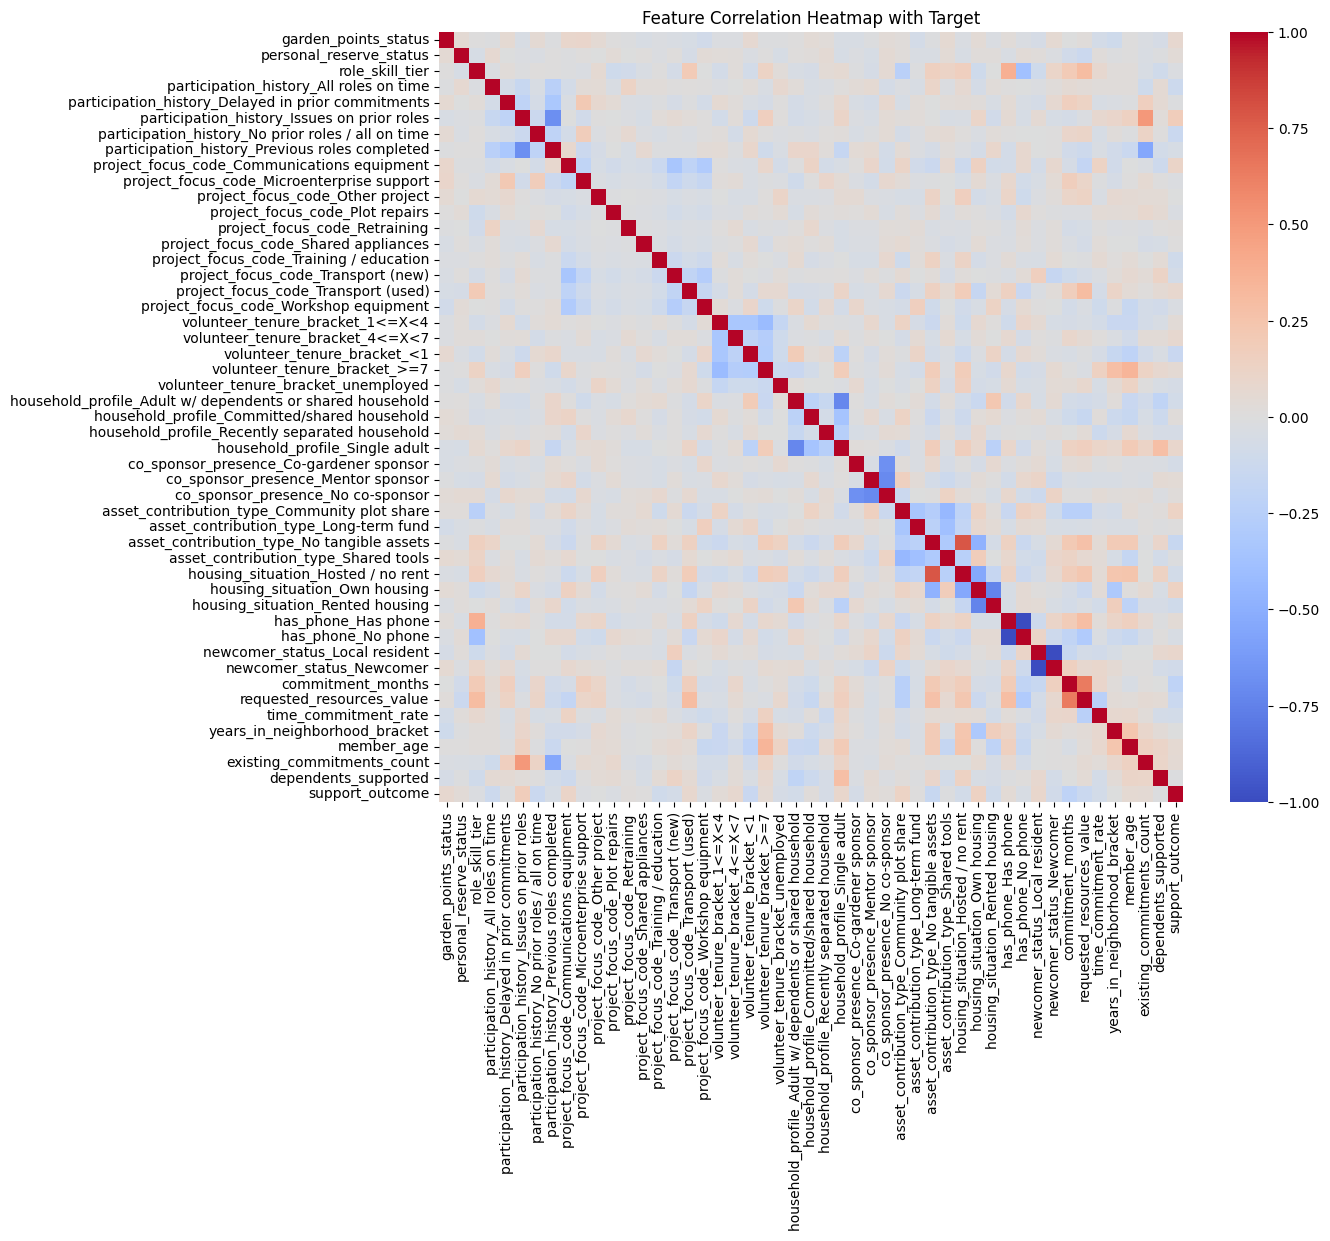

In [ ]:
corr_analysis = df_train_encoded.copy()
corr_analysis['support_outcome'] = y_train
# Plotting the correlation heatmap: 
plt.figure(figsize=(12, 10))
correlation_matrix = corr_analysis.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', cbar=True)
plt.title('Feature Correlation Heatmap with Target')
plt.show()

# 2 - Applying algorithms in the processed dataset:

### 2.1 - Applying Decision Trees:

In [26]:
# Using a cross-validation to find the results from our tree:
dt_classifier = DecisionTreeClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'recall': 'recall_weighted'}

cv_scores = cross_val_score(dt_classifier, df_train_encoded, y_train, cv=kf, scoring='accuracy')
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean()}")
accuracy_dt=cv_scores.mean()

Cross-validation accuracy scores: [0.66875 0.6875  0.70625 0.60625 0.6875 ]
Mean cross-validation accuracy: 0.67125


In [27]:
# Using a grid-search to find the best hyperparameters for DecisionTreeClassifier
param_grid = {
    'max_depth': [5, 10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up the grid search
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search.fit(df_train_encoded, y_train)

# Output the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)
print("Model training and evaluation complete.")

Best parameters found:  {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score:  0.71
Model training and evaluation complete.


In [28]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    df_train_encoded, y_train, test_size=0.2, random_state=42)

In [29]:
# Creating a confusion matrix:
best_dt_classifier = DecisionTreeClassifier(random_state=42, **grid_search.best_params_)
best_dt_classifier.fit(X_train_split, y_train_split)
y_val_pred = best_dt_classifier.predict(X_val_split)
cm = confusion_matrix(y_val_split, y_val_pred)
dt_best_hyperparameters = grid_search.best_params_

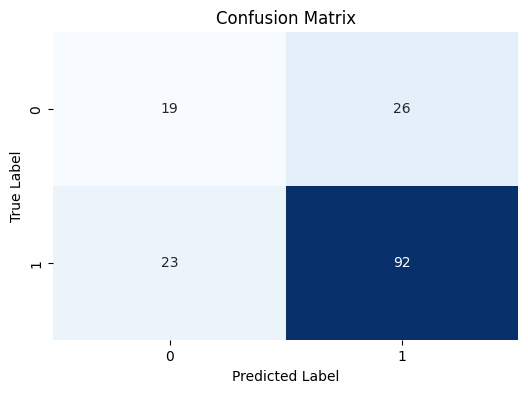

In [30]:
# Ploting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('results/dt_confusion_matrix.png')
plt.show()

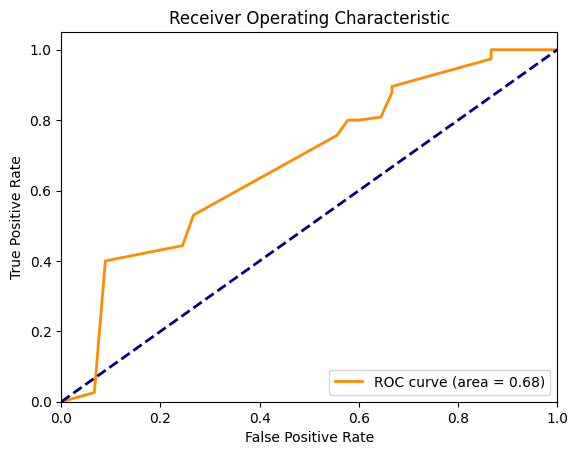

In [31]:
# Plotting AUC and ROC curve
y_val_prob = best_dt_classifier.predict_proba(X_val_split)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val_split, y_val_prob)
roc_auc_dt = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.savefig('results/dt_roc_curve.png')
plt.show()

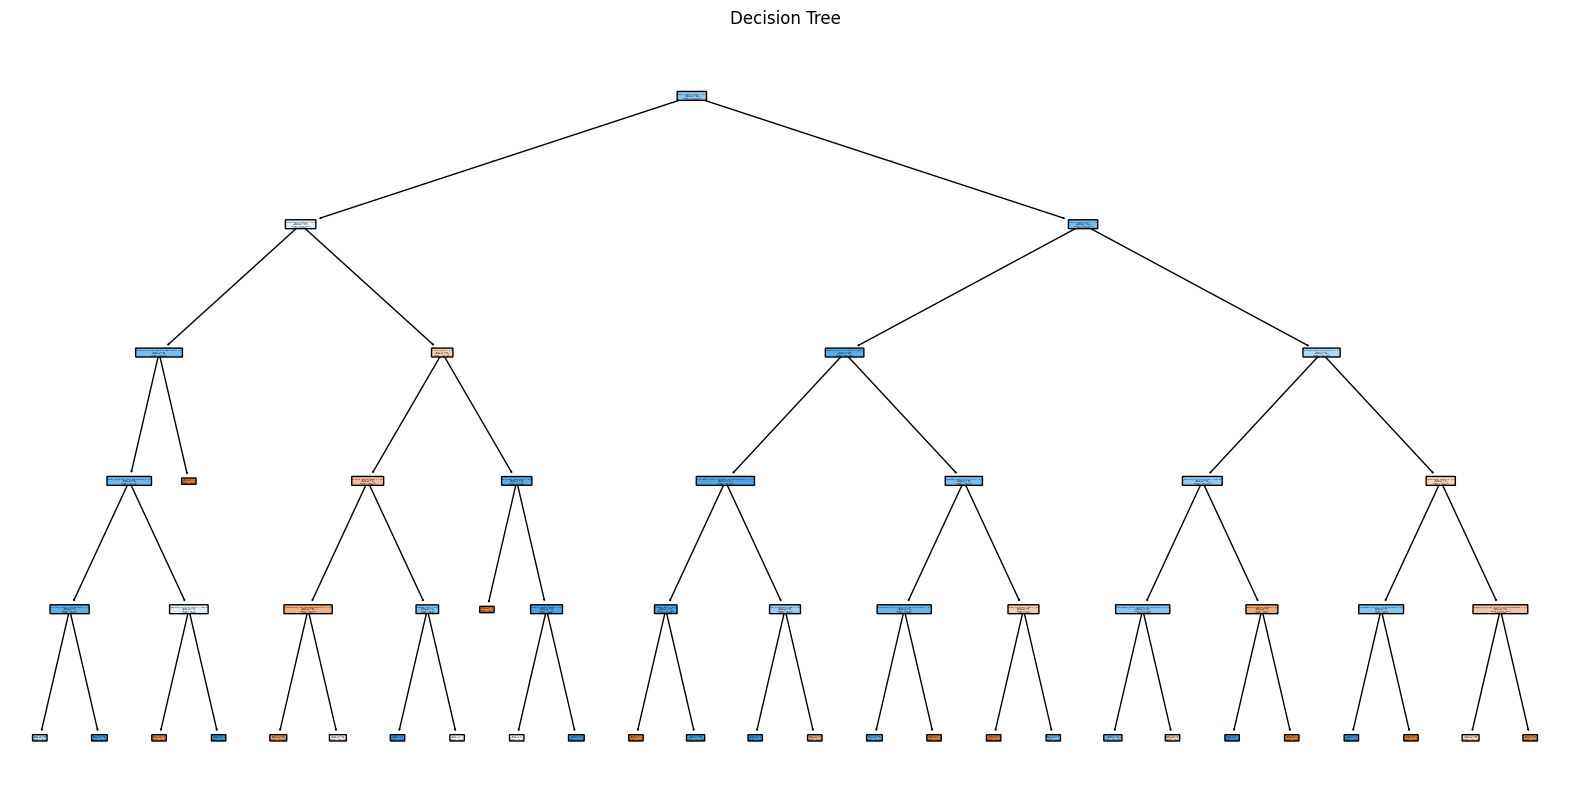

In [32]:
# Plotting the tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt_classifier, filled=True, feature_names=df_train_encoded.columns, class_names=['bad', 'good'], rounded=True)
plt.title('Decision Tree')
plt.show()

### 2.2 -  Applying Random Forest:

In [33]:
# Creating a random forest classifier with grid-search cross-validation
rf_classifier = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_classifier, df_train_encoded, y_train, cv=kf, scoring='accuracy')
print(f"Random Forest Cross-validation accuracy scores: {cv_scores_rf}")
accuracy_rf = cv_scores_rf.mean()

Random Forest Cross-validation accuracy scores: [0.75625 0.7375  0.73125 0.7625  0.7375 ]


In [34]:
# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [3, 5, 10],
    'max_features': ['sqrt', 0.5, 0.7]
}

# Set up the grid search
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid_rf, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(df_train_encoded, y_train)

# Output the best parameters and best score
print("Best parameters found: ", grid_search_rf.best_params_)
print("Best cross-validation score: ", grid_search_rf.best_score_)

Best parameters found:  {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score:  0.745


In [35]:
# Plotting the confusion matrix for Random Forest
best_rf_classifier = RandomForestClassifier(random_state=42, **grid_search_rf.best_params_)
best_rf_classifier.fit(X_train_split, y_train_split)
y_val_pred_rf = best_rf_classifier.predict(X_val_split)
rf_best_hyperparameters = grid_search_rf.best_params_

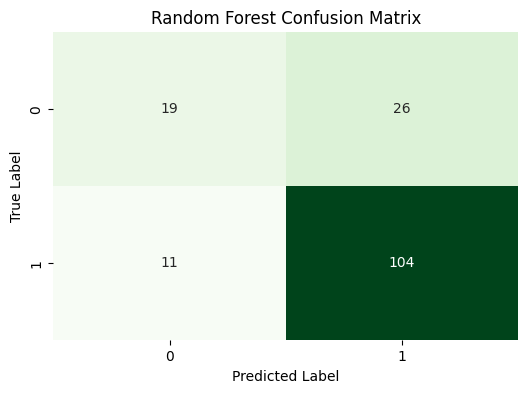

In [36]:
cm_rf = confusion_matrix(y_val_split, y_val_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.savefig('results/rf_confusion_matrix.png')
plt.show()

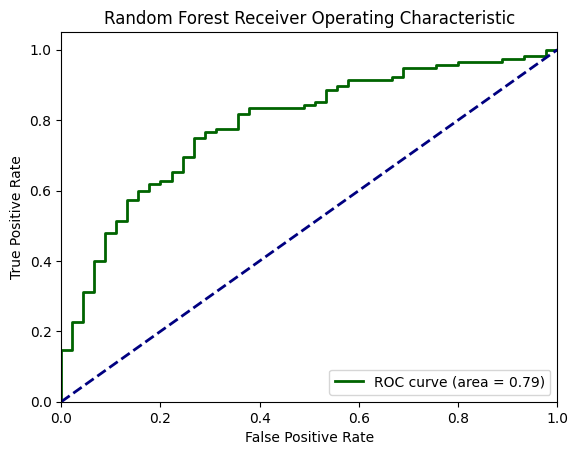

In [37]:
# Plotting the AUC and ROC curve for Random Forest
y_val_prob_rf = best_rf_classifier.predict_proba(X_val_split)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_val_split, y_val_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.savefig('results/rf_roc_curve.png')
plt.show()

### 2.3 -  Applying Gradient Boosting: 

In [38]:
# Using Gradient Boosting with cross-validation to test the results:
gb_classifier = GradientBoostingClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gb = cross_val_score(gb_classifier, df_train_encoded, y_train, cv=kf, scoring='accuracy')
print(f"Gradient Boosting Cross-validation accuracy scores: {cv_scores_gb}")
accuracy_gb = cv_scores_gb.mean()

Gradient Boosting Cross-validation accuracy scores: [0.74375 0.73125 0.73125 0.7375  0.73125]


In [39]:
# Set up the grid search
param_grid_gb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 10]
}
grid_search_gb = GridSearchCV(estimator=gb_classifier, param_grid=param_grid_gb, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_gb.fit(df_train_encoded, y_train)

# Output the best parameters and best score
print("Best parameters found: ", grid_search_gb.best_params_)
print("Best cross-validation score: ", grid_search_gb.best_score_)

Best parameters found:  {'learning_rate': 0.01, 'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation score:  0.7525000000000001


In [40]:
# Plotting the confusion matrix for Gradient Boosting
best_gb_classifier = GradientBoostingClassifier(random_state=42, **grid_search_gb.best_params_)
best_gb_classifier.fit(X_train_split, y_train_split)
y_val_pred_gb = best_gb_classifier.predict(X_val_split)
gb_best_hyperparameters = grid_search_gb.best_params_

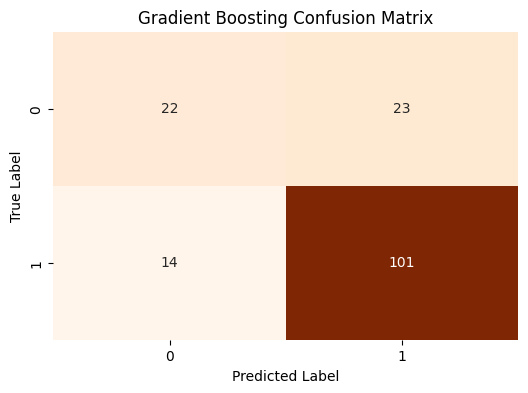

In [41]:
cm_gb = confusion_matrix(y_val_split, y_val_pred_gb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Gradient Boosting Confusion Matrix')
plt.savefig('results/gb_confusion_matrix.png')
plt.show()

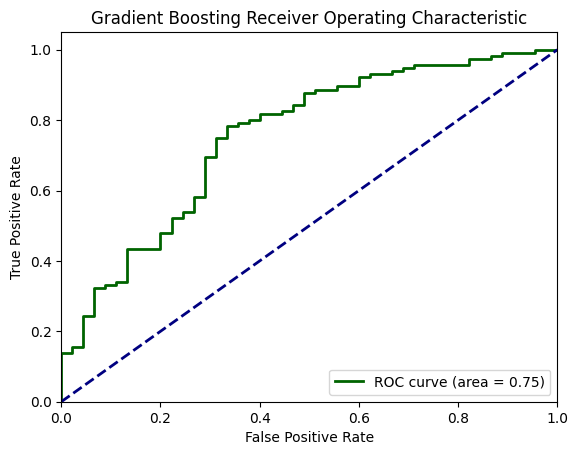

In [42]:
# Plotting the AUC and ROC curve for Random Forest
y_val_prob_rf = best_gb_classifier.predict_proba(X_val_split)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_val_split, y_val_prob_rf)
roc_auc_gb = auc(fpr_rf, tpr_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_gb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.savefig('results/gb_roc_curve.png')
plt.show()

### 2.4 -  Applying Bayes classifier:

In [43]:
# Applying Bayes classifier: 
gnb_classifier = GaussianNB()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gnb = cross_val_score(gnb_classifier, df_train_encoded, y_train, cv=kf, scoring='accuracy')
print(f"Gaussian Naive Bayes Cross-validation accuracy scores: {cv_scores_gnb}")
print(f"Mean cross-validation accuracy: {cv_scores_gnb.mean()}")
accuracy_gnb = cv_scores_gnb.mean()

Gaussian Naive Bayes Cross-validation accuracy scores: [0.65625 0.725   0.66875 0.675   0.60625]
Mean cross-validation accuracy: 0.66625


In [44]:
# Grid search and hyperparameter tuning to GaussianNB
param_grid={'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
grid_search_gnb = GridSearchCV(estimator=gnb_classifier, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search_gnb.fit(df_train_encoded, y_train)
# Output the best parameters and best score
print("Best parameters found: ", grid_search_gnb.best_params_)
print("Best cross-validation score: ", grid_search_gnb.best_score_)

Best parameters found:  {'var_smoothing': 1e-08}
Best cross-validation score:  0.725


In [45]:
# Confusion matrix for Gaussian Naive Bayes with the best hyperparameter:
best_gnb_classifier = GaussianNB(var_smoothing=grid_search_gnb.best_params_['var_smoothing'])
best_gnb_classifier.fit(X_train_split, y_train_split)
y_val_pred_gnb = best_gnb_classifier.predict(X_val_split)
gnb_best_hyperparameters = grid_search_gnb.best_params_

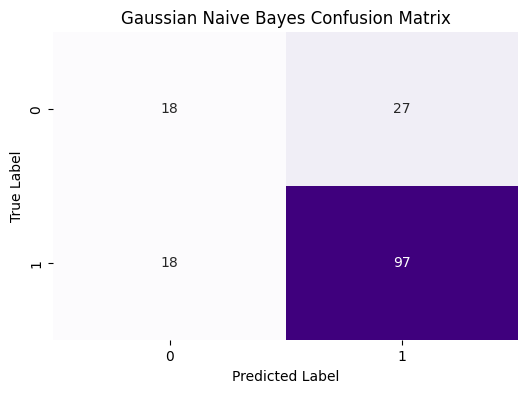

In [46]:
cm_gnb = confusion_matrix(y_val_split, y_val_pred_gnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Gaussian Naive Bayes Confusion Matrix')
plt.savefig('results/gnb_confusion_matrix.png')
plt.show()

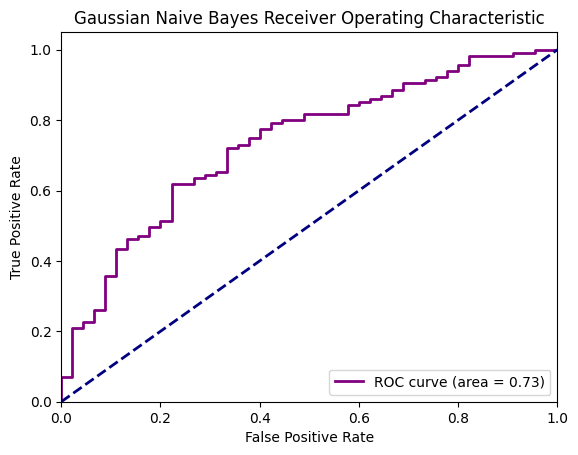

In [47]:
# Plotting the AUC and ROC curve for Gaussian Naive Bayes
y_val_prob_gnb = best_gnb_classifier.predict_proba(X_val_split)[:, 1]
fpr_gnb, tpr_gnb, thresholds_gnb = roc_curve(y_val_split, y_val_prob_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
plt.figure()
plt.plot(fpr_gnb, tpr_gnb, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_gnb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gaussian Naive Bayes Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.savefig('results/gnb_roc_curve.png')
plt.show()

# 3 - Analysing the ROC curve, AUC, and Confusion matrix for each model:

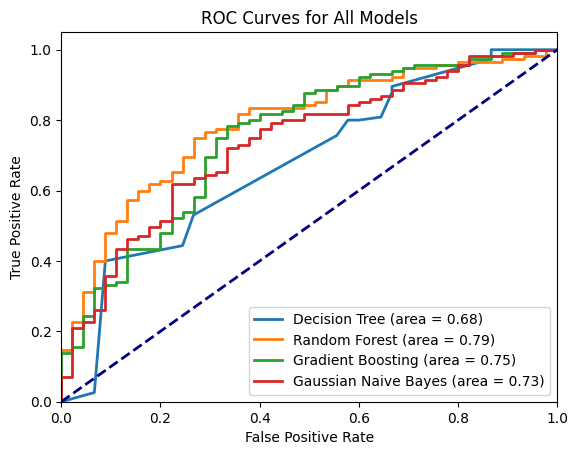

In [48]:
# Plotting the ROC for all models together
plt.figure()
# Decision Tree
y_val_prob_dt = best_dt_classifier.predict_proba(X_val_split)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_val_split, y_val_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, lw=2, label=f'Decision Tree (area = {roc_auc_dt:.2f})')
# Random Forest
y_val_prob_rf = best_rf_classifier.predict_proba(X_val_split)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val_split, y_val_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (area = {roc_auc_rf:.2f})')
# Gradient Boosting
y_val_prob_gb = best_gb_classifier.predict_proba(X_val_split)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_val_split, y_val_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, lw=2, label=f'Gradient Boosting (area = {roc_auc_gb:.2f})')
# Gaussian Naive Bayes
y_val_prob_gnb = best_gnb_classifier.predict_proba(X_val_split)[:, 1]
fpr_gnb, tpr_gnb, _ = roc_curve(y_val_split, y_val_prob_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)
plt.plot(fpr_gnb, tpr_gnb, lw=2, label=f'Gaussian Naive Bayes (area = {roc_auc_gnb:.2f})')
# Plot settings
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.savefig('results/all_models_roc_curve.png')
plt.show()

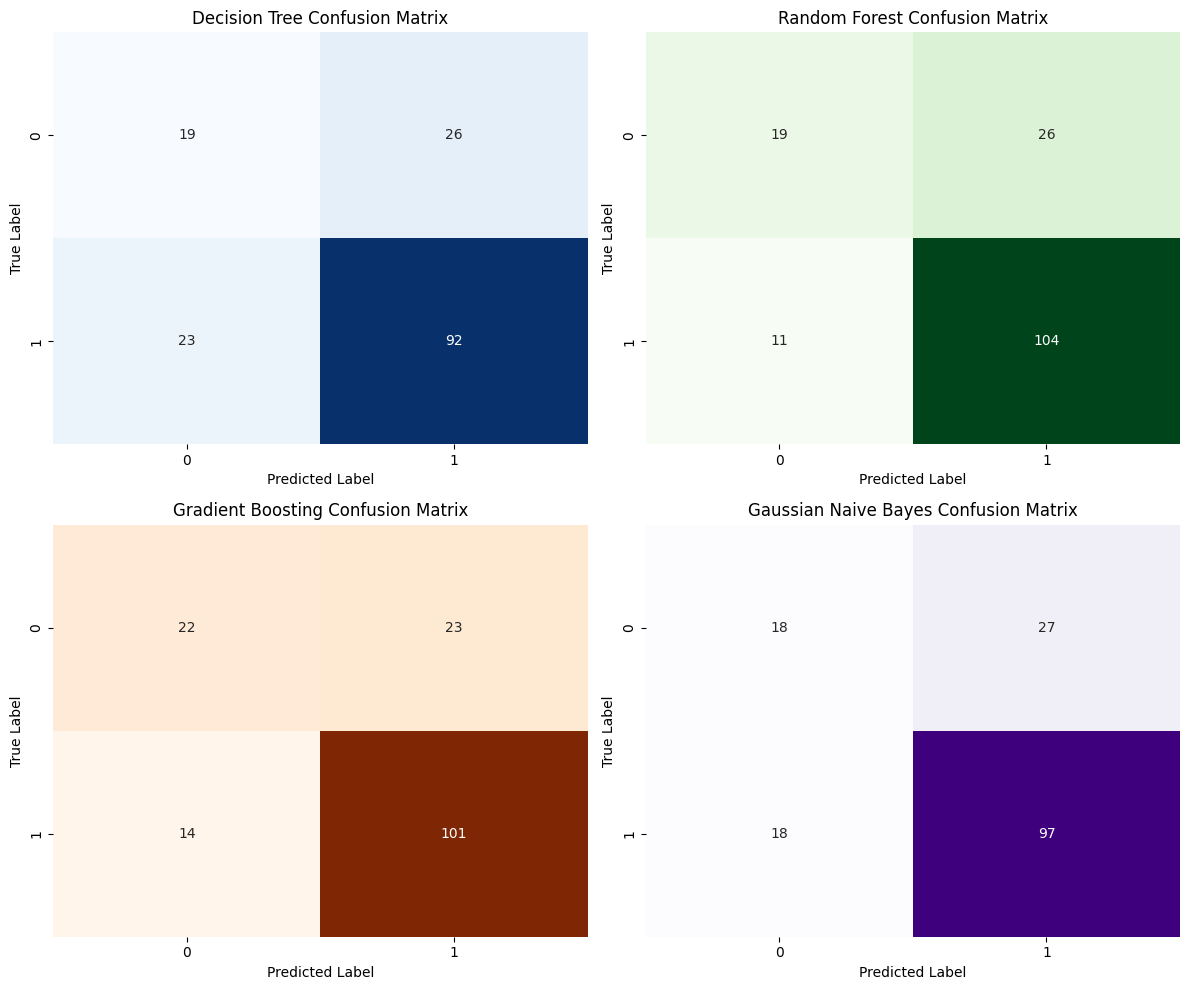

In [49]:
# Plotting all confusion matrices together
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Decision Tree
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_title('Decision Tree Confusion Matrix')
# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_title('Random Forest Confusion Matrix')
# Gradient Boosting
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_title('Gradient Boosting Confusion Matrix')
# Gaussian Naive Bayes
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_title('Gaussian Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.savefig('results/all_models_confusion_matrices.png')
plt.show()

In [50]:
# Creating a table with the best hyperparameters and accuracies of each model
results_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'Gaussian Naive Bayes'],
    'Best Hyperparameters': [dt_best_hyperparameters, rf_best_hyperparameters, gb_best_hyperparameters, gnb_best_hyperparameters],
    'Mean Cross-Validation Accuracy': [accuracy_dt, accuracy_rf, accuracy_gb, accuracy_gnb]
})
results_summary

,Model,Best Hyperparameters,Mean Cross-Validation Accuracy
0,Decision Tree,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.67125
1,Random Forest,"{'max_depth': 10, 'max_features': 0.5, 'min_sa...",0.74500
2,Gradient Boosting,"{'learning_rate': 0.01, 'max_depth': 20, 'min_...",0.73500
3,Gaussian Naive Bayes,{'var_smoothing': 1e-08},0.66625


# 4 - Processing the test file and generating output:

### 4.1 - Opening the file an reading it, and making a general analysis.

In [51]:
df_test= pd.read_csv(os.path.join(folder_data, 'df_test.csv'))
df_test.head()

,id,garden_points_status,commitment_months,participation_history,project_focus_code,requested_resources_value,personal_reserve_status,volunteer_tenure_bracket,time_commitment_rate,household_profile,...,years_in_neighborhood_bracket,asset_contribution_type,member_age,other_support_plans,housing_situation,existing_commitments_count,role_skill_tier,dependents_supported,has_phone,newcomer_status
0,31,Points 0–199,18.0,Previous roles completed,Microenterprise support,1913.0,Reserve: ≥1000,<1,3.0,Committed/shared household,...,3.0,Community plot share,36.0,Partner bank,Own housing,1.0,Skilled volunteer,1.0,Has phone,Newcomer
1,129,Points 0–199,12.0,Issues on prior roles,Transport (used),1860.0,Reserve: <100,unemployed,4.0,Single adult,...,2.0,Shared tools,34.0,NaN,Own housing,2.0,Highly skilled / lead,1.0,Has phone,Newcomer
2,290,Points negative,24.0,Delayed in prior commitments,Communications equipment,1024.0,Reserve: <100,<1,4.0,Committed/shared household,...,4.0,Community plot share,48.0,Partner stores,Own housing,1.0,Skilled volunteer,1.0,No phone,Newcomer
3,217,Points negative,18.0,No prior roles / all on time,Microenterprise support,3104.0,Reserve: <100,4<=X<7,3.0,Single adult,...,1.0,Long-term fund,31.0,Partner bank,Own housing,1.0,Skilled volunteer,1.0,Has phone,Newcomer
4,967,Points 0–199,27.0,Issues on prior roles,Communications equipment,2520.0,Reserve: 500–999,1<=X<4,4.0,Single adult,...,2.0,Long-term fund,23.0,NaN,Own housing,2.0,Unskilled resident,1.0,No phone,Newcomer


In [52]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             200 non-null    int64  
 1   garden_points_status           200 non-null    object 
 2   commitment_months              200 non-null    float64
 3   participation_history          200 non-null    object 
 4   project_focus_code             200 non-null    object 
 5   requested_resources_value      200 non-null    float64
 6   personal_reserve_status        200 non-null    object 
 7   volunteer_tenure_bracket       200 non-null    object 
 8   time_commitment_rate           200 non-null    float64
 9   household_profile              200 non-null    object 
 10  co_sponsor_presence            200 non-null    object 
 11  years_in_neighborhood_bracket  200 non-null    float64
 12  asset_contribution_type        200 non-null    obj

In [53]:
# Counting the number of NaN values in each column of the test dataset
for column in df_test.columns:
    num_missing = df_test[column].isna().sum()
    print(f"Column '{column}' has {num_missing} missing values.")

Column 'id' has 0 missing values.
Column 'garden_points_status' has 0 missing values.
Column 'commitment_months' has 0 missing values.
Column 'participation_history' has 0 missing values.
Column 'project_focus_code' has 0 missing values.
Column 'requested_resources_value' has 0 missing values.
Column 'personal_reserve_status' has 0 missing values.
Column 'volunteer_tenure_bracket' has 0 missing values.
Column 'time_commitment_rate' has 0 missing values.
Column 'household_profile' has 0 missing values.
Column 'co_sponsor_presence' has 0 missing values.
Column 'years_in_neighborhood_bracket' has 0 missing values.
Column 'asset_contribution_type' has 0 missing values.
Column 'member_age' has 0 missing values.
Column 'other_support_plans' has 165 missing values.
Column 'housing_situation' has 0 missing values.
Column 'existing_commitments_count' has 0 missing values.
Column 'role_skill_tier' has 0 missing values.
Column 'dependents_supported' has 0 missing values.
Column 'has_phone' has 0 

### 4.2 - Removing the column with a high number of NaN:

In [54]:
# Removing the column other_support_plans due to high number of missing values (649/800)=~81%
df_test = df_test.drop(columns=['other_support_plans'])

### 4.3 - Transforming the categories columns into useful information:

In [55]:
# Identifying categorical and numerical columns
categorical_cols = df_test.select_dtypes(include=['object']).columns
numerical_cols = df_test.select_dtypes(include=[np.number]).columns
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: Index(['garden_points_status', 'participation_history', 'project_focus_code',
       'personal_reserve_status', 'volunteer_tenure_bracket',
       'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
       'housing_situation', 'role_skill_tier', 'has_phone', 'newcomer_status'],
      dtype='object')
Numerical columns: Index(['id', 'commitment_months', 'requested_resources_value',
       'time_commitment_rate', 'years_in_neighborhood_bracket', 'member_age',
       'existing_commitments_count', 'dependents_supported'],
      dtype='object')


In [56]:
# counting the number of categories for each categorical column
for col in categorical_cols:
    num_categories = df_test[col].nunique()
    print(f"Column '{col}' has {num_categories} unique categories.")
    print(f"The categories are: {df_test[col].unique()}\n")

Column 'garden_points_status' has 4 unique categories.
The categories are: ['Points 0–199' 'Points negative' 'No points account' 'Points 200+']

Column 'participation_history' has 5 unique categories.
The categories are: ['Previous roles completed' 'Issues on prior roles'
 'Delayed in prior commitments' 'No prior roles / all on time'
 'All roles on time']

Column 'project_focus_code' has 10 unique categories.
The categories are: ['Microenterprise support' 'Transport (used)' 'Communications equipment'
 'Workshop equipment' 'Transport (new)' 'Plot repairs' 'Other project'
 'Retraining' 'Training / education' 'Shared appliances']

Column 'personal_reserve_status' has 5 unique categories.
The categories are: ['Reserve: ≥1000' 'Reserve: <100' 'Reserve: 500–999' 'Reserve: 100–499'
 'No reserve']

Column 'volunteer_tenure_bracket' has 5 unique categories.
The categories are: ['<1' 'unemployed' '4<=X<7' '1<=X<4' '>=7']

Column 'household_profile' has 4 unique categories.
The categories are: ['

In [ ]:
# Ordinal Encoding
ordinal_cols = [
    'garden_points_status', 
    'personal_reserve_status', 
    'role_skill_tier'
]

garden_points_categories = ['Points negative', 'No points account', 'Points 0–199', 'Points 200+']
personal_reserve_categories = ['No reserve', 'Reserve: <100', 'Reserve: 100–499', 'Reserve: 500–999', 'Reserve: ≥1000']
role_skill_categories = ['Unemployed / non-resident unskilled', 'Unskilled resident', 'Skilled volunteer', 'Highly skilled / lead']

# Nominal Encoding
nominal_cols = [
    'participation_history', 'project_focus_code', 'volunteer_tenure_bracket', 
    'household_profile', 'co_sponsor_presence', 'asset_contribution_type',
    'housing_situation', 'has_phone', 'newcomer_status'
]

# Numerical columns
numerical_cols = [
    'commitment_months', 'requested_resources_value', 'time_commitment_rate', 
    'years_in_neighborhood_bracket', 'member_age', 'existing_commitments_count', 
    'dependents_supported'
]

In [58]:
df_test.drop(columns=['id'], inplace=True)


In [ ]:
# 4. Create the ColumnTransformer
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[
            garden_points_categories, 
            personal_reserve_categories, 
            role_skill_categories
        ]), ordinal_cols),
        
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        
        ('numeric', 'passthrough', numerical_cols)
    ],
    remainder='drop'
)

In [60]:
# 5. Apply the new preprocessing
x_test_processed = preprocessor_tree.fit_transform(df_test)

ohe_feature_names = preprocessor_tree.named_transformers_['onehot'].get_feature_names_out(nominal_cols)
all_feature_names = ordinal_cols + list(ohe_feature_names) + numerical_cols

# Create the processed DataFrame
df_test_encoded = pd.DataFrame(x_test_processed, columns=all_feature_names, index=df_test.index)

print("New processed test data shape:", df_test_encoded.shape)
df_test_encoded.head()

New processed test data shape: (200, 48)


,garden_points_status,personal_reserve_status,role_skill_tier,participation_history_All roles on time,participation_history_Delayed in prior commitments,participation_history_Issues on prior roles,participation_history_No prior roles / all on time,participation_history_Previous roles completed,project_focus_code_Communications equipment,project_focus_code_Microenterprise support,...,has_phone_No phone,newcomer_status_Local resident,newcomer_status_Newcomer,commitment_months,requested_resources_value,time_commitment_rate,years_in_neighborhood_bracket,member_age,existing_commitments_count,dependents_supported
0,2.0,4.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,18.0,1913.0,3.0,3.0,36.0,1.0,1.0
1,2.0,1.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,12.0,1860.0,4.0,2.0,34.0,2.0,1.0
2,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,24.0,1024.0,4.0,4.0,48.0,1.0,1.0
3,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,18.0,3104.0,3.0,1.0,31.0,1.0,1.0
4,2.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,27.0,2520.0,4.0,2.0,23.0,2.0,1.0


In [61]:
# verifying if there's a categorical
for col in df_test_encoded.columns:
    if df_test_encoded[col].dtype == 'object':
        print(f"Categorical column found: {col}")

In [62]:
# Applying my best model (Random Forest) to the test dataset
y_test_pred_rf = best_rf_classifier.predict(df_test_encoded)

In [63]:
# Verifying the balance of the predictions in percentage for each class:
unique, counts = np.unique(y_test_pred_rf, return_counts=True)
prediction_balance = dict(zip(unique, counts))
total = len(y_test_pred_rf)
prediction_pct = {k: (v / total) * 100 for k, v in prediction_balance.items()}

print("Prediction balance (percentage) per class:")
for cls, pct in sorted(prediction_pct.items()):
    print(f"  Class {cls}: {pct:.2f}% ({prediction_balance[cls]} / {total})")

Prediction balance (percentage) per class:
  Class 0: 18.50% (37 / 200)
  Class 1: 81.50% (163 / 200)


In [64]:
# Converting to a dataset .csv that will have 2 columns: id and y_pred
submission_df = pd.DataFrame({
    'id': pd.read_csv(os.path.join(folder_data, 'df_test.csv'))['id'],
    'support_outcome': np.where(y_test_pred_rf == 1, 'good', 'bad')
})
submission_df.to_csv('results/predicoes_tp_final.csv', index=False)  